#FUENTE:
##"Visión Artificial mediante Aprendizaje Automático con Tensorflow y Pytorch"
###[Web libro:] (https://alfaomegaeditor.com.ar/producto/vision-artificial-mediante-aprendizaje-automatico-con-tensorflow-y-pytorch/#/)

MEDIAPIPE

In [1]:
!pip list | grep media

google-resumable-media                2.7.2
mediapipe                             0.10.14


In [2]:
!pip list | grep numpy

numpy                                 2.3.2


In [22]:
# -*- coding: utf-8 -*-
# MediaPipe: Puntos de la cara y manos
# Adaptado a partir de https://mediapipe.dev/

#Instalar mediapipe
# https://stackoverflow.com/questions/79539921/error-installing-mediapipe-in-google-colab
# https://github.com/google-ai-edge/mediapipe/issues/5817 -> 28/7/25

!pip install --upgrade numpy==2.00
!pip install --upgrade mediapipe==0.10.14

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 47.8 MB/s eta 0:00:00
  Attempting uninstall: mediapipe
    Found existing installation: mediapipe 0.10.21
    Uninstalling mediapipe-0.10.21:
      Successfully uninstalled mediapipe-0.10.21


In [2]:
!pip list | grep mediapipe

mediapipe                             0.10.14


In [6]:
# Cargamos librerías
import cv2
import mediapipe as mp
import numpy as np

In [8]:
print(np.__version__)

2.0.0


In [9]:
print(mp.__version__)

0.10.14


In [10]:
# Herramienta de dibujo de MediaPipe
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
drawing_spec = mp_drawing.DrawingSpec(thickness=2, circle_radius=2)

def dibujar(imagen, face_landmarks, conexiones, estilo):
    mp_drawing.draw_landmarks(
        image=imagen,
        landmark_list=face_landmarks,
        connections=conexiones,
        landmark_drawing_spec=drawing_spec,
        connection_drawing_spec=estilo)

In [11]:
!wget -O Gioconda.jpg https://github.com/palasatenea66/DATASETS/raw/main/Gioconda.jpg

--2025-07-29 04:35:23--  https://github.com/palasatenea66/DATASETS/raw/main/Gioconda.jpg
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/main/Gioconda.jpg [following]
--2025-07-29 04:35:24--  https://raw.githubusercontent.com/palasatenea66/DATASETS/main/Gioconda.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4979635 (4.7M) [image/jpeg]
Saving to: ‘Gioconda.jpg’

Gioconda.jpg        100%[===================>]   4.75M  13.2MB/s    in 0.4s    

2025-07-29 04:35:26 (13.2 MB/s) - ‘Gioconda.jpg’ saved [4979635/4979635]



In [12]:
!ls

Gioconda.jpg  sample_data


In [13]:
# Imagen a procesar:
IMAGEN_RUTA = "Gioconda.jpg"
# Leer imagen OpenCV en RGB
imagen = cv2.imread(IMAGEN_RUTA)
imagenResultado = imagen.copy()
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)


In [15]:
# Tratamos las caras
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5) as face_mesh:

    # Procesar imagen para obtener puntos
    results = face_mesh.process(imagen)

    # Continuamos si hemos detectado puntos
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            # Sacamos por pantalla los valores de los landmarks
            print('face_landmarks: \n', face_landmarks)
            # Dibujamos la malla entre puntos, los contornos y
            # los ojos
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,
                    mp_drawing_styles.get_default_face_mesh_tesselation_style())
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                    mp_drawing_styles.get_default_face_mesh_contours_style())
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_IRISES,
                    mp_drawing_styles.get_default_face_mesh_iris_connections_style())

face_landmarks: 
 landmark {
  x: 0.453512549
  y: 0.301689625
  z: -0.017458776
}
landmark {
  x: 0.44798553
  y: 0.277415872
  z: -0.0424872302
}
landmark {
  x: 0.452427983
  y: 0.282660633
  z: -0.0193282329
}
landmark {
  x: 0.443462461
  y: 0.250766784
  z: -0.0339079872
}
landmark {
  x: 0.447351098
  y: 0.269957662
  z: -0.0465615317
}
landmark {
  x: 0.448371947
  y: 0.259265602
  z: -0.0448678434
}
landmark {
  x: 0.452680886
  y: 0.231641352
  z: -0.0277451575
}
landmark {
  x: 0.403492957
  y: 0.222219855
  z: 0.0192476753
}
landmark {
  x: 0.453895867
  y: 0.21039331
  z: -0.0257118456
}
landmark {
  x: 0.453542471
  y: 0.200109094
  z: -0.029674286
}
landmark {
  x: 0.454666585
  y: 0.160249278
  z: -0.0287845843
}
landmark {
  x: 0.453787088
  y: 0.303609729
  z: -0.0157744437
}
landmark {
  x: 0.454448283
  y: 0.305267394
  z: -0.0123622473
}
landmark {
  x: 0.455322593
  y: 0.306289732
  z: -0.00741840433
}
landmark {
  x: 0.455555856
  y: 0.306317091
  z: -0.008699340

In [17]:
# Tratamos las manos:
mp_hands = mp.solutions.hands

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5) as hands:

    # Hacemos flip sobre la imagen (eje y) para que funcione el modelo
    imagen = cv2.flip(imagen, 1)
    imagenResultado = cv2.flip(imagenResultado, 1)
    # Procesamos la imagen buscando las manos
    results = hands.process(imagen)

    # Sacamos los resultados en pantalla
    if results.multi_hand_landmarks:
        print('Handedness: \n', results.multi_handedness)

        # Recorremos las manos devueltas
        for hand_landmarks in results.multi_hand_landmarks:
            print('Hand_landmarks: \n', hand_landmarks)
            # Dibujamos las manos sobre la imagen resultado
            mp_drawing.draw_landmarks(
                imagenResultado,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
        imagenResultado = cv2.flip(imagenResultado, 1)


Handedness: 
 [classification {
  index: 0
  score: 0.996039689
  label: "Left"
}
]
Hand_landmarks: 
 landmark {
  x: 0.355064422
  y: 0.773061335
  z: 2.32966627e-07
}
landmark {
  x: 0.406783879
  y: 0.75425
  z: 0.00289534731
}
landmark {
  x: 0.460946053
  y: 0.763817668
  z: -0.00119659223
}
landmark {
  x: 0.50533551
  y: 0.778034329
  z: -0.00410192274
}
landmark {
  x: 0.538598478
  y: 0.7880283
  z: -0.00731479609
}
landmark {
  x: 0.46722579
  y: 0.782485783
  z: -0.0302274786
}
landmark {
  x: 0.526728809
  y: 0.811380684
  z: -0.0431835614
}
landmark {
  x: 0.55910188
  y: 0.829985619
  z: -0.0458176807
}
landmark {
  x: 0.579739571
  y: 0.844326377
  z: -0.0438827388
}
landmark {
  x: 0.448599517
  y: 0.807299435
  z: -0.0333842896
}
landmark {
  x: 0.506515801
  y: 0.844494224
  z: -0.0392657295
}
landmark {
  x: 0.535851419
  y: 0.862997174
  z: -0.0338718183
}
landmark {
  x: 0.555737853
  y: 0.873690307
  z: -0.0283402242
}
landmark {
  x: 0.427144915
  y: 0.829142332


In [18]:
# Grabamos la imagen De salida
cv2.imwrite('resultadoGioconda_mediapipe.png', imagenResultado)


True

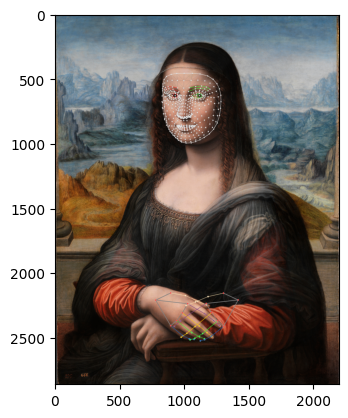

In [19]:
import matplotlib.pyplot as plt
gioconda = 'resultadoGioconda_mediapipe.png'
img = cv2.imread(gioconda)
imageRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(imageRGB)

DLIB68

In [20]:
# -*- coding: utf-8 -*-
# Modelo DLIB de detección de puntos de la cara
from imutils import face_utils
import dlib
import cv2


In [21]:
!wget -O shape_predictor_68_face_landmarks.dat.bz2 https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2

--2025-07-29 04:39:21--  https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/davisking/dlib-models/master/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-07-29 04:39:22--  https://raw.githubusercontent.com/davisking/dlib-models/master/shape_predictor_68_face_landmarks.dat.bz2
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M) [application/octet-stream]
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  52.6MB/s    in 1.2

In [22]:
!ls

Gioconda.jpg			 sample_data
resultadoGioconda_mediapipe.png  shape_predictor_68_face_landmarks.dat.bz2


In [23]:
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

In [24]:
!ls

Gioconda.jpg			 sample_data
resultadoGioconda_mediapipe.png  shape_predictor_68_face_landmarks.dat


In [25]:
# Este modelo utiliza un detector de caras HOG y después
# obtiene los puntos de la cara con DLIB-68, que utiliza
# un modelo de regresión con árboles
# El modelo de regresión está preentrenado y
# se puede descargar de:
# https://github.com/davisking/dlib-models/blob/master/shape_predictor_68_face_landmarks.dat.bz2

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")



In [26]:
# Leemos la imagen con OpenCV
imagen = "Gioconda.jpg"
imge = cv2.imread(imagen)
imRGB = cv2.cvtColor(imge, cv2.COLOR_BGR2RGB)

# Transformamos a escala de grises
gray = cv2.cvtColor(imge, cv2.COLOR_BGR2GRAY)

In [27]:
# Obtenemos las regiones de las caras
rects = detector(gray, 0)

# Para cada cara, encontramos los landmarks (68 puntos)
for (i, rect) in enumerate(rects):
    # Llamamos al modelo
    shape = predictor(gray, rect)
    # Transformamos el resultado en numpy
    shape = face_utils.shape_to_np(shape)

    # Dibujamos los puntos en la imagen
    for (x, y) in shape:
        cv2.circle(imge, (x, y), 8, (0, 255, 0), -1)

In [28]:
# Grabamos imagen
cv2.imwrite("resultadoGiocondaDLIB.png", imge)

True

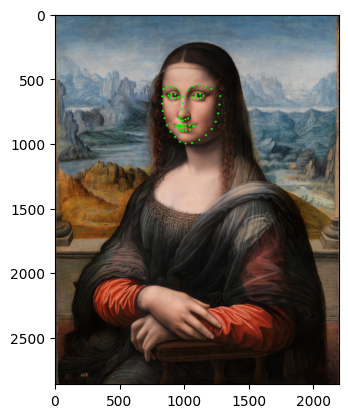

In [29]:
import matplotlib.pyplot as plt
gioconda = 'resultadoGiocondaDLIB.png'
img2 = cv2.imread(gioconda)
imageRGB2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(imageRGB2)